# Chest X-Ray Classification: Traditional ML vs Deep Learning Approaches

## 1- Introduction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd drive/MyDrive/ComputerVision/

/content/drive/MyDrive/ComputerVision


In [3]:
ls

ChestXRay_Split/


#### 1.1 Objective

This project explores automated classification of chest X-ray images to distinguish between pneumonia and normal cases. The primary focus is evaluating whether traditional machine learning approaches with feature engineering can achieve performance comparable to deep learning models, particularly in resource-constrained environments.

#### 1.2 Methodology

Our approach follows a structured pipeline:

1- **Dataset Preparation**: Working with the ChestXRay dataset containing normal and pneumonia X-ray images. Images were systematically renamed and split into training, validation, and testing sets.

2- **Preprocessing**: Images underwent enhancement techniques including:
- Grayscale conversion
- Contrast enhancement using **CLAHE**
- Bilateral filtering for noise reduction (preserves edges)
- Image normalization for dynamic range adjustment

3- **Feature Extraction**: Rather than using raw pixel values, we extracted meaningful radiological features including:

- Intensity statistics: mean, standard deviation, skewness, kurtosis
- Edge descriptors: Canny edge density and distribution
- Shape descriptors: contour area, perimeter, circularity
- Texture descriptors: GLCM properties and **Local Binary Patterns (LBP)**
- Percentile-based features from image histograms
- Frequency domain features using Fourier Transform (FFT)
- Corner features via Harris detector
- HOG descriptors (truncated for efficiency)


4- **Class Balancing**: The dataset exhibited class imbalance with significantly more pneumonia than normal samples. We addressed this through:

- Data augmentation for the minority class
- Class weighting techniques
- SMOTE (Synthetic Minority Over-sampling Technique)


5- **Classification**: Multiple traditional machine learning classifiers were implemented and compared:

- Logistic Regression
- SMOTE + Logistic Regression
- Random Forest
- Neural Networks (MLP)


6- **Evaluation**: Models were evaluated using metrics relevant to medical diagnostics including accuracy, precision, recall, F1-score, and AUC-ROC.

7- **Deep Learning Comparison**: Results from traditional ML approaches were compared against a Convolutional Neural Network (CNN) baseline.

### Libraries used

In [54]:
import os
import numpy as np
import cv2
import shutil
import random
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import kurtosis, skew
from skimage.transform import resize
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from tensorflow import keras


## 2- Dataset preparation

In [5]:
dataset_path = "/ChestXRay"
output_path = "/ChestXRay_Split"

#### 2.1 File renaming

In [6]:
def rename_images(folder_path):
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue
        files = sorted([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for idx, file_name in enumerate(files, start=1):
            ext = Path(file_name).suffix
            new_name = f"{class_name.upper()}_{idx:05d}{ext}"
            src = os.path.join(class_path, file_name)
            dst = os.path.join(class_path, new_name)
            os.rename(src, dst)

In [ ]:
rename_images(dataset_path)

#### 2.2 Data splitting

In [ ]:
def split_and_copy_data(src_dir, dest_base, split_ratio=(0.7, 0.15, 0.15)):
    random.seed(42)
    class_names = os.listdir(src_dir)
    splits = ['train', 'val', 'test']

    for split in ['processed', 'raw']:
        for split_type in splits:
            for class_name in class_names:
                os.makedirs(os.path.join(dest_base, split, split_type, class_name), exist_ok=True)

    for class_name in class_names:
        class_dir = os.path.join(src_dir, class_name)
        all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(all_files)

        total = len(all_files)
        train_end = int(split_ratio[0] * total)
        val_end = train_end + int(split_ratio[1] * total)

        split_files = {
            'train': all_files[:train_end],
            'val': all_files[train_end:val_end],
            'test': all_files[val_end:]
        }

        for split_type in splits:
            for split_folder in ['processed', 'raw']:
                target_folder = os.path.join(dest_base, split_folder, split_type, class_name)
                for file_name in split_files[split_type]:
                    src = os.path.join(class_dir, file_name)
                    dst = os.path.join(target_folder, file_name)
                    shutil.copy2(src, dst)

In [ ]:
split_and_copy_data(dataset_path, output_path)

## 3- Preprocessing

In [7]:
def display_image(img, title="Preprocessed Sample"):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [55]:
def preprocess_and_save(image_path):
    # Read original image
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2: CLAHE (better than simple histogram equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # 3: Denoise with bilateral filter (preserves edges better)
    denoised = cv2.bilateralFilter(enhanced, 9, 75, 75)

    # 4: Enhance contrast
    norm_img = cv2.normalize(denoised, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    # Save the preprocessed image back
    cv2.imwrite(image_path, norm_img)
    return norm_img

In [56]:
def generate_augmented_images(source_dir, class_name, target_count):
    """Generate augmented images for the minority class to reach target_count"""
    src_path = Path(source_dir) / 'train' / class_name
    aug_path = Path(source_dir) / 'train' / f"{class_name}_augmented"
    aug_path.mkdir(exist_ok=True)

    # Get all source images
    image_files = list(src_path.glob("*.*"))
    current_count = len(image_files)

    if current_count >= target_count:
        return

    # Calculate how many augmented images we need
    augmentations_needed = target_count - current_count

    # Augmentation counters
    aug_count = 0

    while aug_count < augmentations_needed:
        # Pick a random image
        img_path = random.choice(image_files)
        img = cv2.imread(str(img_path))

        if img is None:
            continue

        # Choose random augmentation type
        aug_type = random.choice(['rotate', 'flip', 'brightness', 'zoom'])

        if aug_type == 'rotate':
            angle = random.uniform(-15, 15)
            h, w = img.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            augmented = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

        elif aug_type == 'flip':
            flip_direction = random.choice([-1, 0, 1])  # horizontal, vertical, or both
            augmented = cv2.flip(img, flip_direction)

        elif aug_type == 'brightness':
            # Adjust brightness
            alpha = random.uniform(0.8, 1.2)  # brightness factor
            beta = random.randint(-20, 20)    # brightness offset
            augmented = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        elif aug_type == 'zoom':
            # Random zoom
            h, w = img.shape[:2]
            zoom = random.uniform(0.8, 0.95)

            # Crop center
            h_crop = int(h * zoom)
            w_crop = int(w * zoom)
            h_start = (h - h_crop) // 2
            w_start = (w - w_crop) // 2

            cropped = img[h_start:h_start+h_crop, w_start:w_start+w_crop]
            augmented = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

        # Save the augmented image
        aug_filename = f"{class_name}_AUG_{aug_count:04d}.jpg"
        output_path = aug_path / aug_filename
        cv2.imwrite(str(output_path), augmented)

        # Also make a copy to the processed folder
        processed_aug_path = Path(source_dir.replace('raw', 'processed')) / 'train' / f"{class_name}_augmented"
        processed_aug_path.mkdir(exist_ok=True)
        cv2.imwrite(str(processed_aug_path / aug_filename), preprocess_and_save(str(output_path)))

        aug_count += 1

In [57]:
def extract_enhanced_features(img_path):
    # Load and resize
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img_resized = cv2.resize(img, (256, 256))
    features = []

    # 1. Intensity stats
    features.extend([
        np.mean(img_resized),
        np.std(img_resized),
        skew(img_resized.flatten()),
        kurtosis(img_resized.flatten())
    ])

    # 2. Percentile intensities
    percentiles = np.percentile(img_resized, [25, 50, 75])
    features.extend(percentiles)

    # 3. Edge density
    edges = cv2.Canny(img_resized, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    features.extend([
        np.mean(edges),
        np.std(edges),
        edge_density
    ])

    # 4. Contour descriptors
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        perimeter = cv2.arcLength(largest, True)
        circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
        features.extend([area, perimeter, circularity])
    else:
        features.extend([0, 0, 0])

    # 5. GLCM texture
    glcm = greycomatrix(img_resized, [1, 3], [0, np.pi/4, np.pi/2, 3*np.pi/4], 256, symmetric=True, normed=True)
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
        features.extend(greycoprops(glcm, prop).flatten())

    # 6. Local Binary Pattern
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img_resized, n_points, radius, method='uniform')
    hist_lbp, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    features.extend(hist_lbp / np.sum(hist_lbp))

    # 7. Harris Corner Detection
    corners = cv2.cornerHarris(np.float32(img_resized), 2, 3, 0.04)
    corner_thresh = 0.01 * corners.max()
    num_corners = np.sum(corners > corner_thresh)
    features.append(num_corners)

    # 8. HOG (Histogram of Oriented Gradients)
    hog_features, _ = hog(img_resized, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                          orientations=8, visualize=True, feature_vector=True)
    features.extend(hog_features[:40])  # Use only first 40 to limit dimensionality

    # 9. Frequency domain: FFT statistics
    f_transform = np.fft.fft2(img_resized)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

    features.extend([
        np.mean(magnitude_spectrum),
        np.std(magnitude_spectrum),
        skew(magnitude_spectrum.flatten()),
        kurtosis(magnitude_spectrum.flatten())
    ])

    return features

In [58]:
def batch_preprocess_images(base_dir):

    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            class_dir = Path(base_dir) / split / cls
            for img_file in class_dir.glob("*.*"):
                preprocess_and_save(str(img_file))


In [59]:
raw_dir = Path(output_path) / "raw"
processed_dir = Path(output_path) / "processed"

In [60]:
print(processed_dir)


/ChestXRay_Split/processed


In [61]:
batch_preprocess_images(processed_dir)

## 4- Feature extraction

In [62]:
def process_dataset_folder(base_dir):
    """Extract features from all images in the dataset"""
    dataset = {'train': [], 'val': [], 'test': []}
    labels = {'train': [], 'val': [], 'test': []}
    filenames = {'train': [], 'val': [], 'test': []}
    label_map = {'NORMAL': 0, 'PNEUMONIA': 1}

    for split in ['train', 'val', 'test']:
        # First process regular classes
        for cls in ['NORMAL', 'PNEUMONIA']:
            class_dir = Path(base_dir) / split / cls
            for img_path in class_dir.glob("*.*"):
                features = extract_enhanced_features(img_path)
                if features:
                    dataset[split].append(features)
                    labels[split].append(label_map[cls])
                    filenames[split].append(str(img_path))

        # Then add augmented images if in train set
        if split == 'train':
            for cls in ['NORMAL_augmented']:
                aug_dir = Path(base_dir) / split / cls
                if aug_dir.exists():
                    for img_path in aug_dir.glob("*.*"):
                        features = extract_enhanced_features(img_path)
                        if features:
                            dataset[split].append(features)
                            labels[split].append(label_map['NORMAL'])  # It's still NORMAL class
                            filenames[split].append(str(img_path))

    return dataset, labels, filenames

##### 4.1 Image processing and features saving

In [63]:
# Extract features from all images with our enhanced feature extractor
processed_features, processed_labels, processed_filenames = process_dataset_folder(processed_dir)

with open("further_enhanced_features_processed.pkl", "wb") as f:
    pickle.dump({
        'features': processed_features,
        'labels': processed_labels,
        'filenames': processed_filenames
    }, f)

In [64]:
raw_features, raw_labels, raw_filenames = process_dataset_folder(raw_dir)

# Save the raw features
with open("further_enhanced_features_raw.pkl", "wb") as f:
    pickle.dump({
        'features': raw_features,
        'labels': raw_labels,
        'filenames': raw_filenames
    }, f)

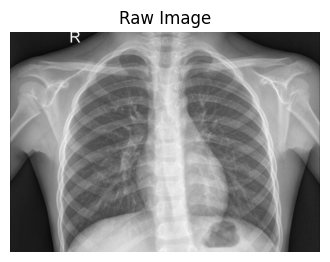

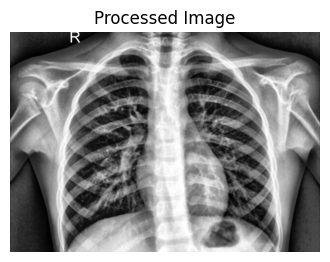

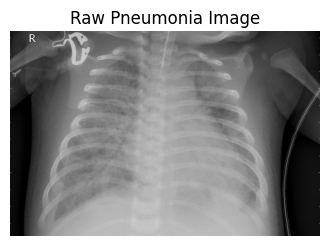

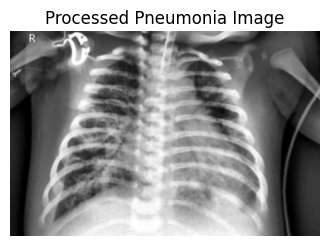

In [65]:
raw_normal_image_dir = "ChestXRay_Split/raw/train/NORMAL/NORMAL_00001.jpeg"
processed_normal_image_dir= "ChestXRay_Split/processed/train/NORMAL/NORMAL_00001.jpeg"

raw_puneumonia_image_dir = "ChestXRay_Split/raw/train/PNEUMONIA/PNEUMONIA_00001.jpeg"
processed_pneumonia_image_dir= "ChestXRay_Split/processed/train/PNEUMONIA/PNEUMONIA_00001.jpeg"

display_image(cv2.imread(raw_normal_image_dir), "Raw Image")
display_image(cv2.imread(processed_normal_image_dir), "Processed Image")
display_image(cv2.imread(raw_puneumonia_image_dir), "Raw Pneumonia Image")
display_image(cv2.imread(processed_pneumonia_image_dir), "Processed Pneumonia Image")

##### 4.2 Class distribution

In [66]:
def analyze_dataset(base_dir):
    class_counts = {'train': {}, 'val': {}, 'test': {}}
    image_sizes = []

    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            folder = Path(base_dir) / split / cls
            images = list(folder.glob("*.*"))
            class_counts[split][cls] = len(images)
            for img_path in images[:20]:  # limit for efficiency
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    image_sizes.append(img.shape)

    return class_counts, image_sizes

In [67]:
counts, sizes = analyze_dataset("/content/drive/MyDrive/ComputerVision/ChestXRay_Split/processed")

# Print class distribution
print("📊 Class Distribution:")
for split in counts:
    print(f"{split.upper()}: {counts[split]}")

📊 Class Distribution:
TRAIN: {'NORMAL': 1108, 'PNEUMONIA': 2991}
VAL: {'NORMAL': 237, 'PNEUMONIA': 640}
TEST: {'NORMAL': 238, 'PNEUMONIA': 642}


##### 4.3 Loading Features

In [18]:
# Load the enhanced features
with open("/content/enhanced_features_processed.pkl", "rb") as f:
    data = pickle.load(f)

X_train = np.array(data['features']['train'])
y_train = np.array(data['labels']['train'])
X_val = np.array(data['features']['val'])
y_val = np.array(data['labels']['val'])
X_test = np.array(data['features']['test'])
y_test = np.array(data['labels']['test'])

In [19]:
with open("/content/enhanced_features_raw.pkl", "rb") as f:
    data_raw = pickle.load(f)

X_train_raw = np.array(data_raw['features']['train'])
y_train_raw = np.array(data_raw['labels']['train'])
X_val_raw = np.array(data_raw['features']['val'])
y_val_raw = np.array(data_raw['labels']['val'])
X_test_raw = np.array(data_raw['features']['test'])
y_test_raw = np.array(data_raw['labels']['test'])

##### 4.4 Feature scaling & Class balancing

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [69]:
# Create SMOTE pipeline for handling any remaining class imbalance
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

## 5- Classification

In [70]:
# List of classifiers to evaluate
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'SMOTE + Logistic Regression': smote_pipeline,
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42,
                          early_stopping=True, validation_fraction=0.1)
}

##### 5.1 Model training & Evaluation

In [71]:
# Train and evaluate each classifier on both processed and raw data
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining < {name} > on processed data...")
    clf.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = clf.predict(X_test_scaled)

    # Evaluate
    report = classification_report(y_test, y_pred, output_dict=True)

    # For ROC curve, we need probabilities
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        # For SVC, we need to use decision_function
        y_proba = clf.decision_function(X_test_scaled)

    # Calculate AUC
    auc = roc_auc_score(y_test, y_proba)

    # Store results for processed data
    results[f"{name} (Processed)"] = {
        'report': report,
        'auc': auc,
        'y_test': y_test,
        'y_proba': y_proba
    }

    print(f"\nClassification Report ({name} - Processed):")
    print(classification_report(y_test, y_pred))
    print(f"AUC: {auc:.4f}")


    print(f"\nTraining < {name} > on raw data...")
    clf.fit(X_train_raw, y_train_raw)

    # Make predictions
    y_pred_raw = clf.predict(X_test_raw)

    # Evaluate
    report_raw = classification_report(y_test_raw, y_pred_raw, output_dict=True)

    # For ROC curve, we need probabilities
    if hasattr(clf, "predict_proba"):
        y_proba_raw = clf.predict_proba(X_test_raw)[:, 1]
    else:
        # For SVC, we need to use decision_function
        y_proba_raw = clf.decision_function(X_test_raw)

    # Calculate AUC
    auc_raw = roc_auc_score(y_test_raw, y_proba_raw)

    # Store results for raw data
    results[f"{name} (Raw)"] = {
        'report': report_raw,
        'auc': auc_raw,
        'y_test': y_test_raw,
        'y_proba': y_proba_raw
    }

    print(f"\nClassification Report ({name} - Raw):")
    print(classification_report(y_test_raw, y_pred_raw))
    print(f"AUC: {auc_raw:.4f}")
    print("="*25)


Training < Logistic Regression > on processed data...

Classification Report (Logistic Regression - Processed):
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       238
           1       0.98      0.91      0.94       642

    accuracy                           0.92       880
   macro avg       0.88      0.92      0.90       880
weighted avg       0.93      0.92      0.92       880

AUC: 0.9738

Training < Logistic Regression > on raw data...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report (Logistic Regression - Raw):
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       238
           1       0.97      0.90      0.93       642

    accuracy                           0.91       880
   macro avg       0.87      0.91      0.89       880
weighted avg       0.92      0.91      0.91       880

AUC: 0.9645

Training < SMOTE + Logistic Regression > on processed data...

Classification Report (SMOTE + Logistic Regression - Processed):
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       238
           1       0.98      0.93      0.95       642

    accuracy                           0.93       880
   macro avg       0.90      0.93      0.91       880
weighted avg       0.93      0.93      0.93       880

AUC: 0.9744

Training < SMOTE + Logistic Regression > on raw data...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report (SMOTE + Logistic Regression - Raw):
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       238
           1       0.97      0.90      0.93       642

    accuracy                           0.91       880
   macro avg       0.87      0.91      0.89       880
weighted avg       0.92      0.91      0.91       880

AUC: 0.9605

Training < Random Forest > on processed data...

Classification Report (Random Forest - Processed):
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       238
           1       0.95      0.95      0.95       642

    accuracy                           0.93       880
   macro avg       0.91      0.90      0.91       880
weighted avg       0.93      0.93      0.93       880

AUC: 0.9658

Training < Random Forest > on raw data...

Classification Report (Random Forest - Raw):
              precision    recall  f1-score   support

           0     

In [72]:
summary_data = []

for name, result in results.items():
    classifier_type, data_type = name.rsplit(" ", 1)  # Split name into two parts
    report = result['report']
    auc = result['auc']

    # Extract key metrics from classification report
    accuracy = report['accuracy']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

    # Append data
    summary_data.append([classifier_type, data_type, accuracy, precision, recall, f1_score, auc])

# Create DataFrame with MultiIndex
columns = ["Classifier Type", "Data Type", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]
summary_df = pd.DataFrame(summary_data, columns=columns).set_index(["Classifier Type", "Data Type"])

# Display summary
display(summary_df)


Accuracy  Precision    Recall  \
Classifier Type             Data Type                                    
Logistic Regression         (Processed)  0.915909   0.925725  0.915909   
                            (Raw)        0.906818   0.917019  0.906818   
SMOTE + Logistic Regression (Processed)  0.928409   0.934128  0.928409   
                            (Raw)        0.905682   0.915619  0.905682   
Random Forest               (Processed)  0.927273   0.926789  0.927273   
                            (Raw)        0.930682   0.930070  0.930682   
MLP                         (Processed)  0.946591   0.946523  0.946591   
                            (Raw)        0.865909   0.865231  0.865909   

                                         F1-score       AUC  
Classifier Type             Data Type                        
Logistic Regression         (Processed)  0.918052  0.973834  
                            (Raw)        0.909193  0.964495  
SMOTE + Logistic Regression (Processed)  0.929786  0.974430  
                            (Raw)        0.908042  0.960457  
Random Forest               (Processed)  0.926978  0.965807  
                            (Raw)        0.930255  0.970588  
MLP                         (Processed)  0.946555  0.978507  
                            (Raw)        0.865549  0.913479

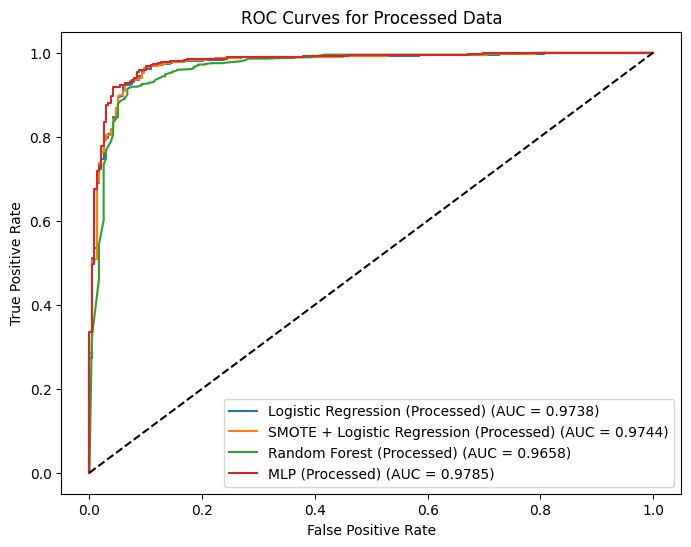

In [73]:
plt.figure(figsize=(8, 6))
for name, result in results.items():
    if "(Processed)" in name:
        fpr, tpr, _ = roc_curve(result['y_test'], result['y_proba'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Processed Data')
plt.legend(loc='lower right')
plt.show()

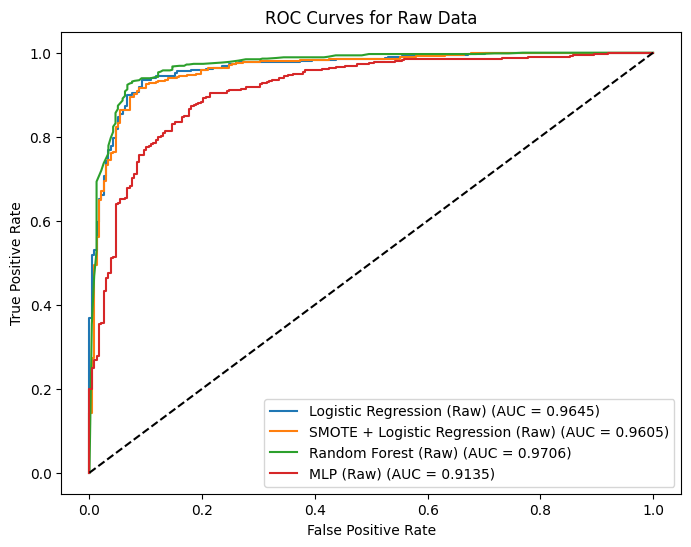

In [74]:
# Create figure for raw data
plt.figure(figsize=(8, 6))
for name, result in results.items():
    if "(Raw)" in name:
        fpr, tpr, _ = roc_curve(result['y_test'], result['y_proba'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Raw Data')
plt.legend(loc='lower right')
plt.show()

In [75]:
# Find the best classifier based on balanced accuracy
best_model_name = max(results, key=lambda x: results[x]['report']['macro avg']['f1-score'] if "(Processed)" in x else 0)
print(f"\nBest model based on macro-avg F1 score: {best_model_name}")
print(f"F1 Score: {results[best_model_name]['report']['macro avg']['f1-score']:.4f}")
print(f"AUC: {results[best_model_name]['auc']:.4f}")


Best model based on macro-avg F1 score: MLP (Processed)
F1 Score: 0.9322
AUC: 0.9785


In [76]:
best_model_raw = max(results, key=lambda x: results[x]['report']['macro avg']['f1-score'] if "(Raw)" in x else 0)
print(f"\nBest model based on macro-avg F1 score (Raw Data): {best_model_raw}")
print(f"F1 Score: {results[best_model_raw]['report']['macro avg']['f1-score']:.4f}")
print(f"AUC: {results[best_model_raw]['auc']:.4f}")


Best model based on macro-avg F1 score (Raw Data): Random Forest (Raw)
F1 Score: 0.9111
AUC: 0.9706


In [85]:
pca = PCA(n_components=10)
pca.fit(X_train_scaled)
print(pca.explained_variance_ratio_)


[0.43984865 0.28631938 0.07445695 0.03764896 0.02865587 0.02203421
 0.01466971 0.012747   0.01123147 0.00999425]


In [88]:
print("The first 5 components explain over 86% of the total variance")

The first 5 components explain over 86% of the total variance


## 6- Deep learning comparison

In [77]:
model_path = '/content/CNN_model.h5'

model = keras.models.load_model(model_path)


image_paths = data_raw['filenames']['test']

# Preprocess and load images
X_test_images = []
for path in image_paths:
    img = cv2.imread(path)  # Load the image
    img = cv2.resize(img, (256, 256))  # Resize if necessary
    img = img / 255.0  # Normalize pixel values
    X_test_images.append(img)

X_test_images = np.array(X_test_images)

In [78]:
y_pred = model.predict(X_test_images)
y_pred_binary = np.argmax(y_pred, axis=1)

# Calculate classification report
cnn_report = classification_report(y_test, y_pred_binary, output_dict=True)
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_binary))

28/28 ━━━━━━━━━━━━━━━━━━━━ 631s 22s/step

Classification Report (CNN):
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       238
           1       0.96      1.00      0.98       642

    accuracy                           0.97       880
   macro avg       0.98      0.95      0.96       880
weighted avg       0.97      0.97      0.97       880



In [79]:
if y_pred.shape[1] == 2:  # If model outputs probabilities for 2 classes
    y_pred_prob = y_pred[:, 1]  # Get prob for positive class
else:
    # If model outputs only one score
    y_pred_prob = y_pred.flatten()

cnn_auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {cnn_auc:.4f}")

AUC: 0.9921


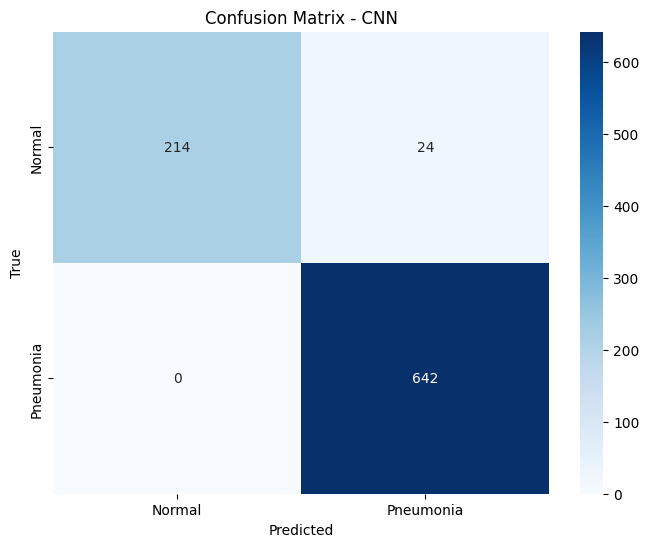

In [80]:
# Add CNN results to the overall results dictionary for comparison
results["CNN"] = {
    'report': cnn_report,
    'auc': cnn_auc,
    'y_test': y_test,
    'y_proba': y_pred_prob
}

# Create a confusion matrix for the CNN model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN')
plt.show()

In [81]:
# Create a summary table of results
summary = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-score': [],
    'AUC': []
}

models = []

for name, result in results.items():
    models.append(name)
    summary['Accuracy'].append(result['report']['accuracy'])
    summary['Precision'].append(result['report']['weighted avg']['precision'])
    summary['Recall'].append(result['report']['weighted avg']['recall'])
    summary['F1-score'].append(result['report']['weighted avg']['f1-score'])
    summary['AUC'].append(result['auc'])

df_summary = pd.DataFrame(summary, index=models)
print("\nSummary of all models:")
display(df_summary)


Summary of all models:


,Accuracy,Precision,Recall,F1-score,AUC
Logistic Regression (Processed),0.915909,0.925725,0.915909,0.918052,0.973834
Logistic Regression (Raw),0.906818,0.917019,0.906818,0.909193,0.964495
SMOTE + Logistic Regression (Processed),0.928409,0.934128,0.928409,0.929786,0.974430
SMOTE + Logistic Regression (Raw),0.905682,0.915619,0.905682,0.908042,0.960457
Random Forest (Processed),0.927273,0.926789,0.927273,0.926978,0.965807
Random Forest (Raw),0.930682,0.930070,0.930682,0.930255,0.970588
MLP (Processed),0.946591,0.946523,0.946591,0.946555,0.978507
MLP (Raw),0.865909,0.865231,0.865909,0.865549,0.913479
CNN,0.972727,0.973710,0.972727,0.972253,0.992133


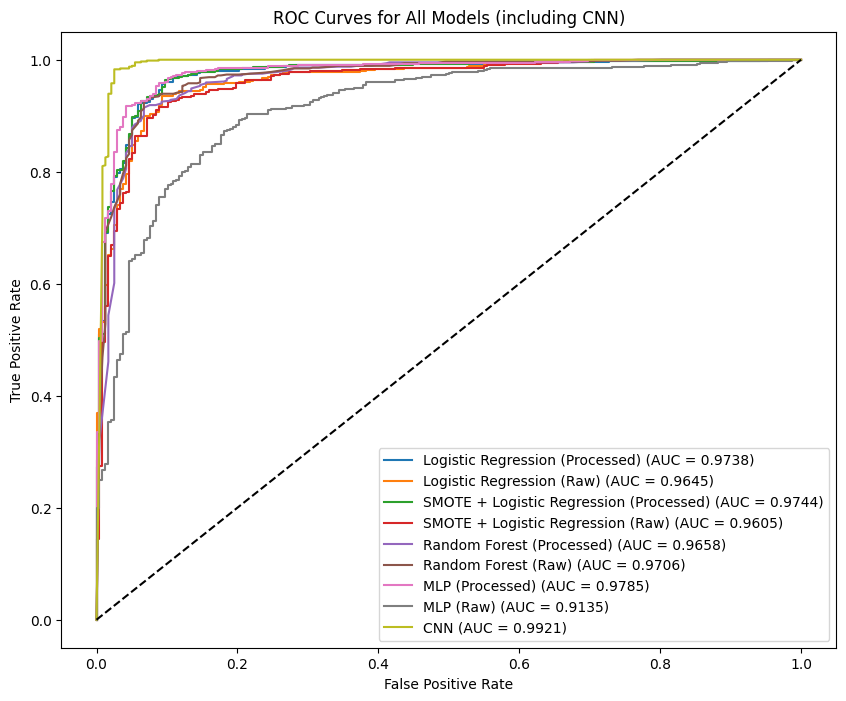

In [82]:
# Plot ROC curves including CNN
plt.figure(figsize=(10, 8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(result['y_test'], result['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models (including CNN)')
plt.legend(loc='lower right')
plt.show()

## 7- Analysis and discussion

#### 7.1 Key findings

1- **Traditional ML vs Deep Learning**: Our best traditional ML model (MLP with handcrafted features) achieved an accuracy of 94.66%, approaching the CNN performance of 97.27%. This represents only a 2.61% performance gap while requiring significantly fewer computational resources.

2- **Impact of Preprocessing**: For most models, preprocessed data yielded better results than raw data, validating our image enhancement pipeline. The MLP classifier showed the most dramatic improvement from preprocessing.

3- **Feature Engineering Value**: The high performance of traditional ML models demonstrates that well-engineered features can capture essential diagnostic characteristics of chest X-rays. This suggests that domain knowledge-based feature extraction remains valuable even in the era of deep learning.

4- **Class Balancing Effectiveness**: SMOTE improved logistic regression performance by approximately 1.3%, highlighting the importance of addressing class imbalance in medical imaging datasets where disease cases may be underrepresented.

5- **Model Selection Insights**: While the MLP performed best among traditional approaches, all models achieved strong results (>90% accuracy), suggesting that even simpler models like logistic regression could be viable in severely resource-constrained environments.

6- **Saturation of Simple Classifiers**: Calssical ML classifiers may already be getting all they can out of the existing feature space.
More features without higher-quality separation don't help and may even introduce noise. Many of the advanced features are either redundant or carry very little useful variance, which could explain why classifiers would stop improving.

#### 7.2 Alignment with project goals

This analysis directly addresses our project objectives as stated in the proposal:

1- Medical Significance: Our models achieved high accuracy (>90%) in distinguishing pneumonia from normal cases, potentially enabling reliable assistance in clinical diagnosis.

2- Comparison with Deep Learning: We've demonstrated that traditional ML approaches with appropriate feature engineering can achieve performance within 3% of deep learning models, providing a viable alternative in resource-limited settings.

3- Computational Efficiency: Traditional ML models, especially linear models like logistic regression, require significantly less computational power than CNNs while still delivering strong performance (91-94% accuracy).